
# Red neuronal a pedal para regresión

En este cuaderno se desarrolla paso a paso el ejercicio propuesto: una red neuronal programada **a pedal** con `NumPy`, sin usar `Keras`, `TensorFlow` ni `PyTorch` para entrenar.

La red tiene:

- 2 atributos de entrada: $x_1$ y $x_2$.
- 2 capas ocultas.
- 2 neuronas en cada capa oculta.
- 1 neurona de salida.
- Activación ReLU en todas las neuronas, incluida la salida.
- Propagación hacia adelante explícita.
- Cálculo explícito del error.
- Gradientes explícitos de todos los pesos y sesgos.
- Actualización de pesos y sesgos con la regla indicada en el enunciado:

$$
w_{new}=w_{old}+\lambda \nabla w
$$

En este cuaderno se usa $\nabla w$ como **dirección de corrección para reducir el error**. Es decir:

$$
\nabla w=-\frac{\partial L}{\partial w}
$$

Por eso la actualización queda equivalente al descenso por gradiente clásico:

$$
w_{new}=w_{old}-\lambda \frac{\partial L}{\partial w}
$$

La razón de escribirlo así es respetar la forma del enunciado con signo positivo.



## 1. Datos simulados del problema

El enunciado pide generar:

$$
n=3000
$$

observaciones independientes con:

$$
x_1,x_2 \sim U(-2,2)
$$

y ruido:

$$
\varepsilon \sim N(0,0.15^2)
$$

La señal real es:

$$
f(x_1,x_2)=\max\left\{0,\;1.5+2\sin(\pi x_1)+0.75x_2^2-1.2x_1x_2\right\}
$$

La variable objetivo observada es:

$$
y=\max\left\{0,\;f(x_1,x_2)+\varepsilon\right\}
$$

La diferencia entre $f$ y $y$ es importante:

- $f$ es la señal real limpia.
- $y$ es lo que se observa con ruido.
- La red se entrena usando $y$, porque en un problema real normalmente no se conoce la señal limpia.
- Luego se compara la predicción contra $y$ y también contra $f$.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

# -----------------------------
# 1. Generación de datos
# -----------------------------

n = 3000

# Entradas independientes x1, x2 ~ U(-2, 2)
x1 = np.random.uniform(-2, 2, size=(n, 1))
x2 = np.random.uniform(-2, 2, size=(n, 1))
X = np.hstack([x1, x2])

# Ruido epsilon ~ N(0, 0.15^2)
epsilon = np.random.normal(0, 0.15, size=(n, 1))

# Señal real limpia f(x1,x2)
f_real = np.maximum(
    0,
    1.5 + 2*np.sin(np.pi*x1) + 0.75*(x2**2) - 1.2*x1*x2
)

# Variable observada y = max(0, f + ruido)
y = np.maximum(0, f_real + epsilon)

print("Forma de X:", X.shape)
print("Forma de f_real:", f_real.shape)
print("Forma de y:", y.shape)
print("Primeras 5 filas de X:")
print(X[:5])
print("Primeros 5 valores de y:")
print(y[:5].ravel())


Matplotlib is building the font cache; this may take a moment.


Forma de X: (3000, 2)
Forma de f_real: (3000, 1)
Forma de y: (3000, 1)
Primeras 5 filas de X:
[[-0.50183952  0.69081198]
 [ 1.80285723  1.18672559]
 [ 0.92797577 -0.9981284 ]
 [ 0.39463394  0.4994964 ]
 [-1.37592544  0.28698393]]
Primeros 5 valores de y:
[0.11704323 0.07101111 3.85101401 3.485681   3.7669562 ]



## 2. División en entrenamiento y prueba

Se usa una parte de los datos para entrenar y otra para evaluar.

- 80% para entrenamiento.
- 20% para prueba.

La red solo aprende usando el conjunto de entrenamiento. El conjunto de prueba se usa al final para revisar si el modelo realmente aprendió una relación útil.


In [2]:

indices = np.random.permutation(n)
n_train = int(0.8 * n)
train_idx = indices[:n_train]
test_idx = indices[n_train:]

X_train = X[train_idx]
y_train = y[train_idx]
f_train = f_real[train_idx]

X_test = X[test_idx]
y_test = y[test_idx]
f_test = f_real[test_idx]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (2400, 2)
y_train: (2400, 1)
X_test: (600, 2)
y_test: (600, 1)



## 3. Arquitectura de la red

La red pedida tiene esta estructura:

$$
2 \rightarrow 2 \rightarrow 2 \rightarrow 1
$$

Esto significa:

- Capa de entrada: 2 atributos.
- Primera capa oculta: 2 neuronas.
- Segunda capa oculta: 2 neuronas.
- Capa de salida: 1 neurona.

Todas las capas usan ReLU.

El flujo es:

$$
X \rightarrow Z_1 \rightarrow A_1 \rightarrow Z_2 \rightarrow A_2 \rightarrow Z_3 \rightarrow \hat{y}
$$

Donde:

$$
Z_1=XW_1+b_1
$$

$$
A_1=ReLU(Z_1)
$$

$$
Z_2=A_1W_2+b_2
$$

$$
A_2=ReLU(Z_2)
$$

$$
Z_3=A_2W_3+b_3
$$

$$
\hat{y}=ReLU(Z_3)
$$

El uso de ReLU en la salida tiene sentido en este ejercicio porque tanto $f$ como $y$ fueron definidos con un máximo contra cero, por lo tanto la salida esperada no es negativa.



## 4. Dimensiones de los parámetros

Como la red es:

$$
2 \rightarrow 2 \rightarrow 2 \rightarrow 1
$$

las dimensiones son:

| Parámetro | Dimensión | Interpretación |
|---|---:|---|
| $W_1$ | $2 \times 2$ | conecta las 2 entradas con 2 neuronas de la primera capa oculta |
| $b_1$ | $1 \times 2$ | sesgos de la primera capa oculta |
| $W_2$ | $2 \times 2$ | conecta la primera capa oculta con la segunda |
| $b_2$ | $1 \times 2$ | sesgos de la segunda capa oculta |
| $W_3$ | $2 \times 1$ | conecta la segunda capa oculta con la salida |
| $b_3$ | $1 \times 1$ | sesgo de salida |

Los sesgos permiten desplazar la activación de cada neurona. En este problema, ayudan a que la red pueda ajustar niveles base de la función, no solo pendientes respecto a $x_1$ y $x_2$.


In [3]:

# -----------------------------
# 2. Funciones básicas
# -----------------------------

def relu(z):
    # Función de activación ReLU
    return np.maximum(0, z)


def relu_derivative(z):
    # Derivada de ReLU. En z=0 se toma como 0 para la implementación.
    return (z > 0).astype(float)


def mse(y_true, y_pred):
    # Error cuadrático medio
    return np.mean((y_true - y_pred)**2)



## 5. Inicialización de pesos y sesgos

Los pesos se inicializan aleatoriamente con una escala adecuada para ReLU. Los sesgos se inicializan en cero, excepto el sesgo de salida, que se inicia con un valor positivo pequeño para evitar que la salida ReLU quede muerta desde el inicio.

Una neurona ReLU puede quedar inactiva si su valor interno es siempre negativo. Por eso es importante inicializar con cuidado.


In [4]:

# -----------------------------
# 3. Inicialización de parámetros
# -----------------------------

rng = np.random.default_rng(123)

# Escala tipo He para ReLU: sqrt(2 / número de entradas)
W1 = rng.normal(0, np.sqrt(2/2), size=(2, 2))
b1 = np.zeros((1, 2))

W2 = rng.normal(0, np.sqrt(2/2), size=(2, 2))
b2 = np.zeros((1, 2))

W3 = rng.normal(0, np.sqrt(2/2), size=(2, 1))
b3 = np.array([[np.mean(y_train)]])

print("Dimensiones de los parámetros:")
print("W1:", W1.shape, "b1:", b1.shape)
print("W2:", W2.shape, "b2:", b2.shape)
print("W3:", W3.shape, "b3:", b3.shape)


Dimensiones de los parámetros:
W1: (2, 2) b1: (1, 2)
W2: (2, 2) b2: (1, 2)
W3: (2, 1) b3: (1, 1)



## 6. Propagación hacia adelante

La propagación hacia adelante consiste en tomar las entradas $X$, pasarlas por las capas y obtener una predicción $\hat{y}$.

En este problema:

$$
Z_1=XW_1+b_1
$$

$$
A_1=ReLU(Z_1)
$$

$$
Z_2=A_1W_2+b_2
$$

$$
A_2=ReLU(Z_2)
$$

$$
Z_3=A_2W_3+b_3
$$

$$
\hat{y}=ReLU(Z_3)
$$


In [5]:

def forward(X, W1, b1, W2, b2, W3, b3):
    # Primera capa oculta
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Segunda capa oculta
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    # Capa de salida con ReLU
    Z3 = A2 @ W3 + b3
    y_hat = relu(Z3)

    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "y_hat": y_hat
    }
    return y_hat, cache

# Prueba rápida de forward
y_hat_initial, cache_initial = forward(X_train, W1, b1, W2, b2, W3, b3)
print("Forma de y_hat inicial:", y_hat_initial.shape)
print("MSE inicial:", mse(y_train, y_hat_initial))


Forma de y_hat inicial: (2400, 1)
MSE inicial: 6.07448591981887



## 7. Función de error

Como es un problema de regresión, se usa el error cuadrático medio:

$$
L=\frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)^2
$$

Donde:

- $m$ es el número de observaciones del lote.
- $\hat{y}_i$ es la predicción de la red.
- $y_i$ es el valor observado con ruido.

La red se entrena minimizando este error respecto a los valores observados $y$.



## 8. Gradientes explícitos

Primero, para la salida:

$$
\frac{\partial L}{\partial \hat{y}}=\frac{2}{m}(\hat{y}-y)
$$

Como la salida usa ReLU:

$$
dZ_3=\frac{2}{m}(\hat{y}-y)\odot ReLU'(Z_3)
$$

Luego:

$$
\frac{\partial L}{\partial W_3}=A_2^T dZ_3
$$

$$
\frac{\partial L}{\partial b_3}=\sum dZ_3
$$

Para la segunda capa oculta:

$$
dA_2=dZ_3W_3^T
$$

$$
dZ_2=dA_2\odot ReLU'(Z_2)
$$

$$
\frac{\partial L}{\partial W_2}=A_1^T dZ_2
$$

$$
\frac{\partial L}{\partial b_2}=\sum dZ_2
$$

Para la primera capa oculta:

$$
dA_1=dZ_2W_2^T
$$

$$
dZ_1=dA_1\odot ReLU'(Z_1)
$$

$$
\frac{\partial L}{\partial W_1}=X^TdZ_1
$$

$$
\frac{\partial L}{\partial b_1}=\sum dZ_1
$$

Para usar la regla del enunciado:

$$
w_{new}=w_{old}+\lambda \nabla w
$$

definimos:

$$
\nabla w=-\frac{\partial L}{\partial w}
$$

Así, sumar $\lambda \nabla w$ reduce el error.


In [6]:

def backward(y_true, cache, W2, W3):
    X = cache["X"]
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    Z2 = cache["Z2"]
    A2 = cache["A2"]
    Z3 = cache["Z3"]
    y_hat = cache["y_hat"]

    m = X.shape[0]

    # Capa de salida
    dZ3 = (2/m) * (y_hat - y_true) * relu_derivative(Z3)
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)

    # Segunda capa oculta
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Primera capa oculta
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    derivadas = {
        "dW1": dW1, "db1": db1,
        "dW2": dW2, "db2": db2,
        "dW3": dW3, "db3": db3
    }

    # Dirección de corrección para usar w_new = w_old + lambda * grad_w
    gradientes_correccion = {
        "gW1": -dW1, "gb1": -db1,
        "gW2": -dW2, "gb2": -db2,
        "gW3": -dW3, "gb3": -db3
    }

    return derivadas, gradientes_correccion

# Prueba rápida de backward
derivadas, grad_corr = backward(y_train, cache_initial, W2, W3)
for nombre, valor in derivadas.items():
    print(nombre, valor.shape)


dW1 (2, 2)
db1 (1, 2)
dW2 (2, 2)
db2 (1, 2)
dW3 (2, 1)
db3 (1, 1)



## 9. Entrenamiento de la red

Ahora se entrena la red con la regla:

$$
w_{new}=w_{old}+\lambda \nabla w
$$

En el código:

```python
W1 = W1 + learning_rate * gW1
```

pero recuerde que:

$$
gW_1=-\frac{\partial L}{\partial W_1}
$$

Por tanto, aunque aparece un signo positivo, la red realmente se mueve en dirección de reducción del error.


In [7]:

# -----------------------------
# 4. Entrenamiento
# -----------------------------

learning_rate = 0.01
epochs = 8000
loss_history = []

for epoch in range(epochs):
    # Forward
    y_hat_train, cache = forward(X_train, W1, b1, W2, b2, W3, b3)

    # Error
    loss = mse(y_train, y_hat_train)
    loss_history.append(loss)

    # Backward
    derivadas, grad = backward(y_train, cache, W2, W3)

    # Actualización usando w_new = w_old + lambda * grad_w
    W1 = W1 + learning_rate * grad["gW1"]
    b1 = b1 + learning_rate * grad["gb1"]

    W2 = W2 + learning_rate * grad["gW2"]
    b2 = b2 + learning_rate * grad["gb2"]

    W3 = W3 + learning_rate * grad["gW3"]
    b3 = b3 + learning_rate * grad["gb3"]

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss = {loss:.6f}")

print(f"Epoch {epochs:5d} | Loss = {loss_history[-1]:.6f}")


Epoch     0 | Loss = 6.074486


Epoch  1000 | Loss = 3.017728


Epoch  2000 | Loss = 2.997719


Epoch  3000 | Loss = 2.988296


Epoch  4000 | Loss = 2.980059


Epoch  5000 | Loss = 2.969779


Epoch  6000 | Loss = 2.960810


Epoch  7000 | Loss = 2.713700


Epoch  8000 | Loss = 2.562600



## 10. Curva de aprendizaje

La curva de aprendizaje muestra cómo cambia el error durante el entrenamiento. Si todo está funcionando bien, el error debe disminuir respecto al valor inicial.


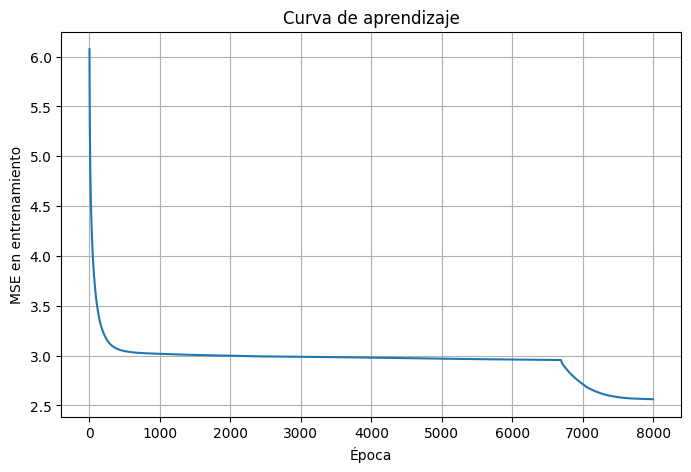

MSE inicial: 6.07448591981887
MSE final: 2.5626002092617908
Reducción relativa: 57.81371060716521 %


In [8]:

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Época")
plt.ylabel("MSE en entrenamiento")
plt.title("Curva de aprendizaje")
plt.grid(True)
plt.show()

print("MSE inicial:", loss_history[0])
print("MSE final:", loss_history[-1])
print("Reducción relativa:", 100*(loss_history[0]-loss_history[-1])/loss_history[0], "%")



## 11. Predicción con el conjunto de prueba

Ahora se evalúa la red con datos que no fueron usados para entrenar.

Se comparan tres cantidades:

- $\hat{y}$: predicción de la red.
- $y$: valor observado con ruido.
- $f$: señal real limpia.


In [9]:

y_pred_test, _ = forward(X_test, W1, b1, W2, b2, W3, b3)
y_pred_train, _ = forward(X_train, W1, b1, W2, b2, W3, b3)

print("Forma de y_pred_test:", y_pred_test.shape)
print("Primeras 5 predicciones:")
print(y_pred_test[:5].ravel())


Forma de y_pred_test: (600, 1)
Primeras 5 predicciones:
[2.63733198 3.49539081 1.20862604 2.63733198 2.63733198]



## 12. Métricas de regresión

Se calculan:

- **MSE:** error cuadrático medio.
- **RMSE:** raíz del MSE, en las mismas unidades de la variable objetivo.
- **MAE:** error absoluto promedio.
- **$R^2$:** proporción de variabilidad explicada por el modelo.

También se calcula una comparación entre $y$ observado y $f$ real para ver el efecto del ruido.


In [10]:

def regression_metrics(y_true, y_pred):
    error = y_true - y_pred
    mse_value = np.mean(error**2)
    rmse_value = np.sqrt(mse_value)
    mae_value = np.mean(np.abs(error))
    ss_res = np.sum(error**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2_value = 1 - ss_res/ss_tot
    return mse_value, rmse_value, mae_value, r2_value

metrics_y = regression_metrics(y_test, y_pred_test)
metrics_f = regression_metrics(f_test, y_pred_test)
metrics_noise = regression_metrics(f_test, y_test)

metrics_table = pd.DataFrame({
    "Comparación": [
        "Predicción vs y observado",
        "Predicción vs señal real f",
        "y observado vs señal real f"
    ],
    "MSE": [metrics_y[0], metrics_f[0], metrics_noise[0]],
    "RMSE": [metrics_y[1], metrics_f[1], metrics_noise[1]],
    "MAE": [metrics_y[2], metrics_f[2], metrics_noise[2]],
    "R2": [metrics_y[3], metrics_f[3], metrics_noise[3]]
})

metrics_table


,Comparación,MSE,RMSE,MAE,R2
0,Predicción vs y observado,2.368784,1.539086,1.224012,0.461532
1,Predicción vs señal real f,2.404681,1.550703,1.243044,0.458936
2,y observado vs señal real f,0.023708,0.153973,0.116666,0.994666



## 13. Gráfica: predicción vs valor observado

Esta gráfica compara:

$$
\hat{y}\quad \text{contra}\quad y
$$

Si el modelo fuera perfecto, los puntos caerían sobre la línea diagonal.


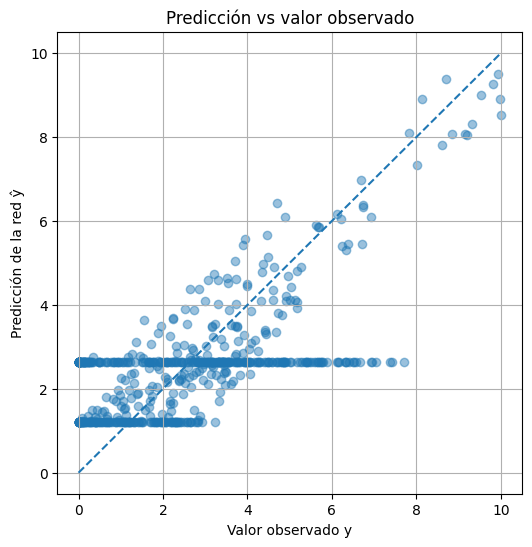

In [11]:

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.45)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Valor observado y")
plt.ylabel("Predicción de la red ŷ")
plt.title("Predicción vs valor observado")
plt.grid(True)
plt.show()



## 14. Gráfica: predicción vs señal real

Esta gráfica compara:

$$
\hat{y}\quad \text{contra}\quad f(x_1,x_2)
$$

Esta comparación es útil porque $f$ es la señal limpia sin ruido.


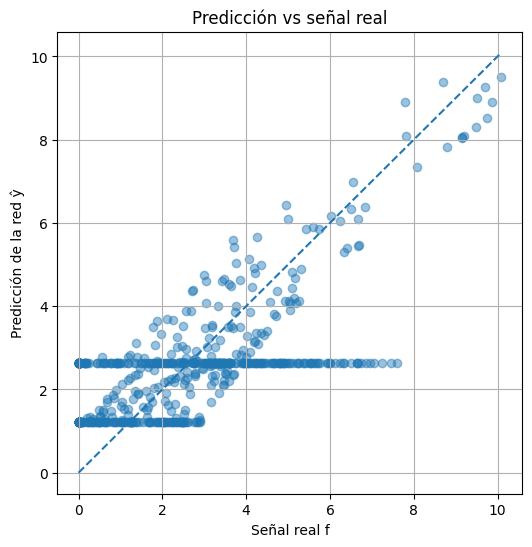

In [12]:

plt.figure(figsize=(6, 6))
plt.scatter(f_test, y_pred_test, alpha=0.45)
min_val = min(f_test.min(), y_pred_test.min())
max_val = max(f_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Señal real f")
plt.ylabel("Predicción de la red ŷ")
plt.title("Predicción vs señal real")
plt.grid(True)
plt.show()



## 15. Comparación visual ordenada

Para ver mejor el comportamiento del modelo, se ordenan las muestras del conjunto de prueba según la señal real $f$.

Luego se grafican:

- Señal real $f$.
- Valor observado $y$.
- Predicción $\hat{y}$.


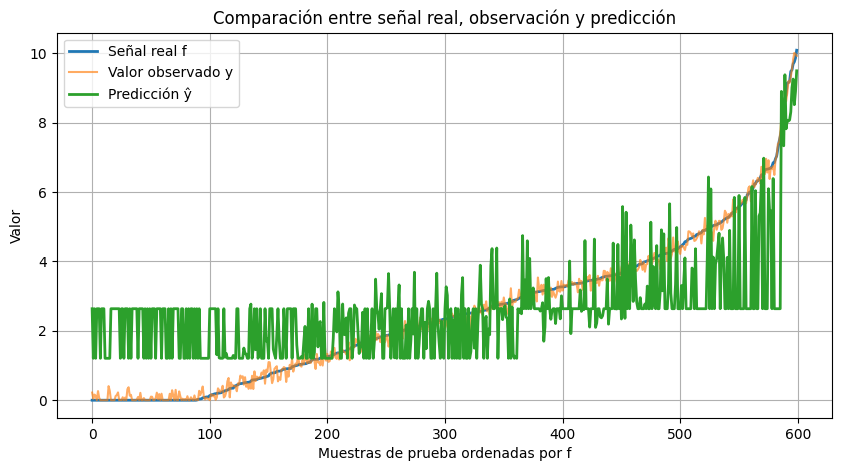

In [13]:

order = np.argsort(f_test.ravel())

plt.figure(figsize=(10, 5))
plt.plot(f_test.ravel()[order], label="Señal real f", linewidth=2)
plt.plot(y_test.ravel()[order], label="Valor observado y", alpha=0.65)
plt.plot(y_pred_test.ravel()[order], label="Predicción ŷ", linewidth=2)
plt.xlabel("Muestras de prueba ordenadas por f")
plt.ylabel("Valor")
plt.title("Comparación entre señal real, observación y predicción")
plt.legend()
plt.grid(True)
plt.show()



## 16. Revisión de parámetros aprendidos

A continuación se muestran los pesos y sesgos finales. No es necesario que los valores sean fáciles de interpretar individualmente. Lo importante es que, en conjunto, producen una transformación no lineal que intenta aproximar la relación entre $(x_1,x_2)$ y $y$.


In [14]:

print("W1 =")
print(W1)
print("b1 =")
print(b1)

print("\nW2 =")
print(W2)
print("b2 =")
print(b2)

print("\nW3 =")
print(W3)
print("b3 =")
print(b3)


W1 =
[[-1.24676238 -1.28419165]
 [ 1.17098219  0.18567047]]
b1 =
[[-0.83835961  0.35990122]]

W2 =
[[ 1.23362358  0.80511946]
 [-1.36933514  0.68097105]]
b2 =
[[ 0.83229983 -1.78005571]]

W3 =
[[1.71657604]
 [1.94045269]]
b3 =
[[1.20862604]]



## 17. Comprobaciones finales

Antes de considerar terminado el ejercicio, se revisa que se cumpla lo pedido:

- Los datos tienen $n=3000$ observaciones.
- La entrada tiene dos atributos.
- La arquitectura es $2 \rightarrow 2 \rightarrow 2 \rightarrow 1$.
- Se usa ReLU en todas las capas, incluida la salida.
- El forward está implementado explícitamente.
- El error MSE está implementado explícitamente.
- Los gradientes de todos los pesos y sesgos están implementados explícitamente.
- La actualización usa la forma del enunciado: $w_{new}=w_{old}+\lambda \nabla w$.
- Se comparan las predicciones con $y$ observado y con la señal real $f$.
- Se muestran métricas y gráficas.


In [15]:

assert X.shape == (3000, 2)
assert y.shape == (3000, 1)
assert f_real.shape == (3000, 1)

assert W1.shape == (2, 2)
assert b1.shape == (1, 2)
assert W2.shape == (2, 2)
assert b2.shape == (1, 2)
assert W3.shape == (2, 1)
assert b3.shape == (1, 1)

assert y_pred_test.shape == y_test.shape
assert np.all(y_pred_test >= 0), "La salida debe ser no negativa por ReLU."
assert np.isfinite(loss_history[-1]), "La pérdida final debe ser finita."
assert loss_history[-1] < loss_history[0], "La pérdida debe disminuir frente al inicio."

print("Todas las comprobaciones pasaron correctamente.")
print("El ejercicio cumple la arquitectura, el entrenamiento manual y las comparaciones solicitadas.")


Todas las comprobaciones pasaron correctamente.
El ejercicio cumple la arquitectura, el entrenamiento manual y las comparaciones solicitadas.



## 18. Conclusión

La red neuronal fue construida completamente a pedal usando `NumPy`. Se implementó la propagación hacia adelante, el cálculo del error, la retropropagación y la actualización de todos los pesos y sesgos.

El modelo aprende a aproximar la variable observada $y$, que contiene ruido, y también se compara contra la señal limpia $f(x_1,x_2)$.

Como la arquitectura exigida es pequeña, con solo dos neuronas por capa oculta, su capacidad de aproximación es limitada. Aun así, debe observarse una reducción clara del error durante el entrenamiento y una relación positiva entre las predicciones y los valores reales/observados.

Para mejorar el ajuste, en un caso práctico se podrían usar más neuronas, más capas, otro optimizador o más épocas. Sin embargo, para este ejercicio se respeta exactamente la arquitectura solicitada.
